## Getting started
First we load in some timeseries data for a single VDS, so that we can have something to work with

In [ ]:
# 3rd party imports
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import statsmodels.api as sm
import typing
import sys
from pathlib import Path
from scipy.stats import norm, beta, weibull_min, cauchy, laplace, hypsecant
from statsmodels.tsa import stattools

# Local imports
from transportation_models.utils.calibration import get_metadata_series_by_id
from transportation_models.utils.constants import *
from transportation_models.utils.representation import Freeway
from transportation_models.utils.validation import validate_timestamp_dtype
from transportation_models.utils.data_processing import normalize_timeseries

# Specify location of files
root_path = "/Users/robstallman/Library/CloudStorage/OneDrive-UCB-O365/Data/PeMS_Data"
# root_path = "/Volumes/easystore/work/boulder/Caltrans/PeMS"
metadata_filename = "metadata/station_metadata_CALIBRATED.csv"
timeseries_directory = os.path.join(root_path, "timeseries_data")
station_id = 407219
#timeseries_filename = f"csv_files/{station_id}.csv"
timeseries_filename = f"{station_id}.csv"
metadata_path = os.path.join(root_path, metadata_filename)
timeseries_path = os.path.join(timeseries_directory, timeseries_filename)

def load_timeseries_by_id(
    timeseries_directory: str = "/Users/robstallman/Library/CloudStorage/OneDrive-UCB-O365/Data/PeMS_Data/csv_files", 
    station_id: str = "400698"
    ) -> pd.DataFrame:
    # Build the full filepath based on the station ID
    filename = f"{station_id}.csv"
    filepath = os.path.join(timeseries_directory, filename)

    # Load the timeseries dataframe
    df = pd.read_csv(filepath)

    # Ensure that the timestamp column exists and is a datetime object
    df = validate_timestamp_dtype(df)

    # Ensure complete indices
    years_in_df = df['timestamp'].dt.year.unique()
    range_start = f"{str(years_in_df.min())}-01-01 00:00"
    range_end = f"{str(years_in_df.max())}-12-31 23:59"
    full_date_range = pd.date_range(start=range_start, end=range_end, freq='5min')
    df_reindexed = df.set_index('timestamp').reindex(full_date_range)
    df_reindexed.reset_index(names='timestamp', inplace=True)

    return df_reindexed

# Load data
metadata_df = pd.read_csv(metadata_path)
detector_metadata = get_metadata_series_by_id(metadata_df, station_id)
print(detector_metadata)
timeseries_df = load_timeseries_by_id(timeseries_directory=timeseries_directory, station_id=station_id)
df = normalize_timeseries(detector_metadata=detector_metadata, timeseries_df=timeseries_df)
df

Station ID                                                   407219
Date                                                     07/21/2022
Name                                              S of Mission Blvd
Lanes                                                             6
Type                                                       Mainline
Sensor Type                                                   loops
Fwy                                                          I880-N
District                                                          4
County                                                      Alameda
City                                                        Fremont
HOV                                                              No
MS ID                                                         DT949
IRM                                               L6-N-33-880-R0163
Status                                                       Active
CA PM                                           

,timestamp,pct_observed,total_flow_[veh/5-min],avg_speed_[mph],normalized_flow_[veh/hr-lane],normalized_density_[veh/mi-lane]
0,2024-01-01 00:00:00,100.0,83.0,69.8,166.0,2.378223
1,2024-01-01 00:05:00,100.0,81.0,65.6,162.0,2.469512
2,2024-01-01 00:10:00,100.0,106.0,62.9,212.0,3.370429
3,2024-01-01 00:15:00,100.0,119.0,66.1,238.0,3.600605
4,2024-01-01 00:20:00,100.0,208.0,64.1,416.0,6.489860
...,...,...,...,...,...,...
105403,2024-12-31 23:35:00,0.0,218.0,64.7,436.0,6.738794
105404,2024-12-31 23:40:00,0.0,217.0,65.2,434.0,6.656442
105405,2024-12-31 23:45:00,0.0,209.0,65.4,418.0,6.391437
105406,2024-12-31 23:50:00,0.0,205.0,65.4,410.0,6.269113


array([<Axes: xlabel='timestamp'>, <Axes: xlabel='timestamp'>,
       <Axes: xlabel='timestamp'>], dtype=object)

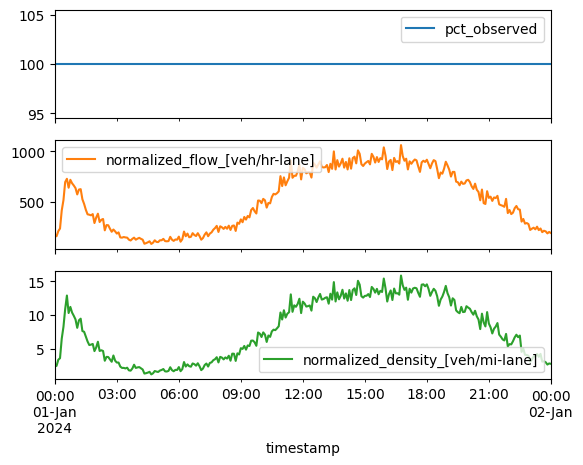

In [16]:
# Visualize the timeseries
ts_start = pd.Timestamp(year=2024, month=1, day=1)
ts_end = pd.Timestamp(year=2024, month=1, day=2)
df.loc[((df['timestamp'] >= ts_start) & (df['timestamp'] <= ts_end)), ['timestamp', 'pct_observed', 'normalized_flow_[veh/hr-lane]', 'normalized_density_[veh/mi-lane]']].set_index('timestamp').plot(subplots=True)

## Trend Stationarity
Based on the shape of the timeseries data that we see above, we might suspect that there is some kind of trend stationarity to the data (i.e., counts on Monday afternoon at 5pm this week are probably similar to counts at 5pm on Monday next week).
Going off of this, let's now build some tools to analyze the trend. We'll want:
1) A function to calculate some aggregate statistics (e.g., mean, variance, etc.) of the timeseries after it has been grouped into bins which we expect to be stationary (e.g., Mondays at 5pm)
2) A function to eliminate the seasonal variation in our timeseries (in the hopes that the result *is* weakly stationary)
3) A function to analyze how stationary the result is

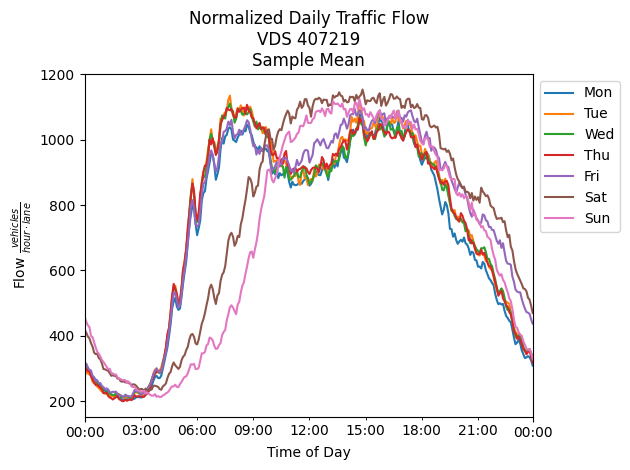

In [17]:
# Define day-of-week to int mapping
day_of_week_mapping = {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

# Build Function #1: calculate aggregate statistics
def get_daily_aggregation(
    df: pd.DataFrame,
    station_id: str,
    metric: str = 'flow',
    aggregation_type: str = 'mean',
    include_plot: bool = True,
    plot_filename: typing.Optional[str] = None):
    # Generate some derived temporal qualities from the timestamp
    df['weekday'] = df['timestamp'].dt.weekday
    df['5min_block'] = (df['timestamp'].dt.minute / 60) + (df['timestamp'].dt.hour)
    df['15min_block'] = (df['timestamp'].dt.floor('15min').dt.minute / 60) + (df['timestamp'].dt.hour)    

    # Pick out relevant columns from the df
    if metric == 'flow':
        plot_title = f"Normalized Daily Traffic Flow\nVDS {station_id}"
        y_axis_label = "Flow " + "$\\frac{vehicles}{hour \cdot lane}$"
        df = df.loc[:,["5min_block", "weekday", "normalized_flow_[veh/hr-lane]"]]
    elif metric == 'density':
        plot_title = f"Normalized Daily Traffic Density\nVDS {station_id}"
        y_axis_label = "Density " + "$\\frac{vehicles}{mile \cdot lane}$"
        df = df.loc[:,["5min_block", "weekday", "normalized_density_[veh/mi-lane]"]]
    else:
        raise ValueError(f"Unrecognized value for 'metric' passed: {metric}. Use one of ['flow', 'density'].")

    # Calculate the aggregation type for the metric for each (t,weekday) index
    if aggregation_type == 'mean':
        aggregation_df = df.groupby(["5min_block", "weekday"]).mean().unstack('weekday')
        title_suffix = "Sample Mean"
    elif aggregation_type == 'std_dev':
        aggregation_df = df.groupby(["5min_block", "weekday"]).std().unstack('weekday')
        title_suffix = "Sample Standard Deviation"
    else:
        raise ValueError(f"Unknown aggregation type provided: {aggregation_type}. Please use one of ['mean','std_dev']")

    # Drop the metric index and map the weekday integers onto days of the week
    aggregation_df.columns = aggregation_df.columns.get_level_values('weekday').map(day_of_week_mapping)

    # Translate the time information in '5min_block' back into a timestamp & use this as the index
    aggregation_df.reset_index(inplace=True)
    aggregation_df['timestamp'] = pd.to_timedelta(aggregation_df["5min_block"], unit="h").apply(lambda x: (pd.Timestamp("1970-01-01") + x)).dt.round(freq='5min')
    aggregation_df.set_index('timestamp', inplace=True)
    #aggregation_df.drop('5min_block', inplace=True, axis=1)

    # Generate a plot
    if include_plot:
        ax = aggregation_df.drop('5min_block', axis=1).plot()
        ax.legend(loc='upper left', bbox_to_anchor=(1,1))
        ax.set_xlabel("Time of Day")
        ax.set_ylabel(y_axis_label)
        ax.set_title(plot_title + f"\n{title_suffix}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        plt.tight_layout()
        if plot_filename is not None:
            if not os.path.exists("plots"):
                os.mkdir("plots")
            plt.savefig(f"plots/{plot_filename}.png")
    
    return aggregation_df

# Look at the results!
aggregation_df = get_daily_aggregation(df, station_id=station_id, aggregation_type='mean', metric='flow', include_plot=True, plot_filename='400698_normalized_stddev_density')

In [18]:
# Helper function for Function #2
def get_agg_value(row: pd.Series, agg_df: pd.DataFrame) -> float:
    """
    Look up an aggregated statistic (e.g., mean, std_dev) for a given time block (expressed as a (day_of_week, 5min_block) combination)

    Parameters
    ----------
    row : pd.Series
        A row in the full timeseries dataframe for a given VDS
    agg_df : pd.DataFrame
        A DataFrame containing the desired aggregation statistics for the VDS

    Returns
    -------
    agg: float
        The value in agg_df corresponding to the (day_of_week, 5min_block) combination in row
    """
    day_of_week = day_of_week_mapping.get(row['weekday'], np.nan)
    time_block = row['5min_block']
    agg = agg_df.loc[aggregation_df['5min_block'] == time_block, day_of_week].values[0]
    return agg

# Function #2: Removing the seasonal variation!
def whiten_timeseries(df: pd.DataFrame, metric: str = 'flow', rho_crit: typing.Optional[float] = None) -> pd.DataFrame:
    # Validate the metric type
    if metric == 'flow':
        colname = 'normalized_flow_[veh/hr-lane]'
    elif metric == 'density':
        colname = 'normalized_density_[veh/mi-lane]'
    else:
        raise ValueError(f"Unrecognized value for 'metric' passed: {metric}. Use one of ['flow', 'density'].")

    # Select relevant columns from df
    sub_df = df.loc[:, ["timestamp", colname]]

    # Generate some derived temporal qualities from the timestamp
    sub_df['weekday'] = sub_df['timestamp'].dt.weekday
    sub_df['5min_block'] = (sub_df['timestamp'].dt.minute / 60) + (sub_df['timestamp'].dt.hour)

    # Get the mean and standard deviation
    mean_df = get_daily_aggregation(df, station_id=station_id, metric=metric, aggregation_type='mean', include_plot=False)
    stddev_df = get_daily_aggregation(df, station_id=station_id, metric=metric, aggregation_type='std_dev', include_plot=False)

    # Add columns for mean and standard deviation
    sub_df['mean'] = sub_df.apply(lambda row: get_agg_value(row, agg_df=mean_df), axis=1)
    sub_df['std_dev'] = sub_df.apply(lambda row: get_agg_value(row, agg_df=stddev_df), axis=1)

    # Center the timeseries metric
    sub_df['centered_data'] = (sub_df[colname] - sub_df['mean'])
    sub_df['whitened_data'] = sub_df['centered_data']/sub_df['std_dev']

    # Optionally evaluate the congestion
    if metric == 'density' and rho_crit is not None:
        sub_df['density_factor'] = sub_df[colname] / rho_crit
    
    # Return the result
    return sub_df

Text(0.5, 1.0, 'Normalized & Whitened Density\nVDS 407219')

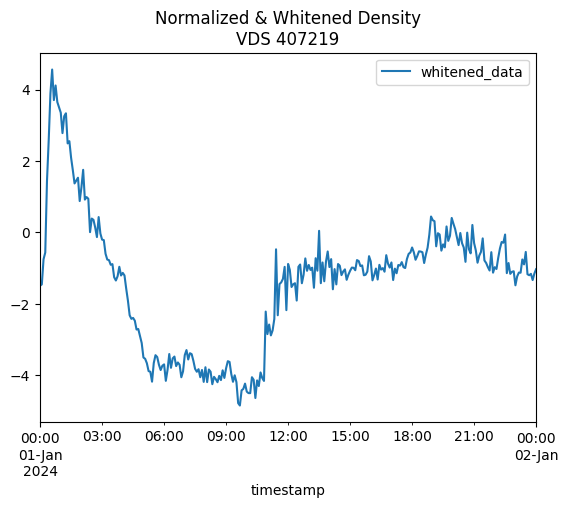

In [20]:
# Visualize the results!
metric = 'density'
whitened_df = whiten_timeseries(df, metric=metric, rho_crit=None)
ts_start = pd.Timestamp(year=2024, month=1, day=1)
ts_end = pd.Timestamp(year=2024, month=1, day=2)
ax = whitened_df.loc[((whitened_df['timestamp'] >= ts_start) & (whitened_df['timestamp'] <= ts_end)), ['timestamp', 'whitened_data']].set_index('timestamp').plot()
ax.set_title(f"Normalized & Whitened {metric.title()}\nVDS {station_id}")

In [21]:
whitened_df

,timestamp,normalized_density_[veh/mi-lane],weekday,5min_block,mean,std_dev,centered_data,whitened_data
0,2024-01-01 00:00:00,2.378223,0,0.000000,4.752220,1.587555,-2.373996,-1.495379
1,2024-01-01 00:05:00,2.469512,0,0.083333,4.686112,1.517328,-2.216600,-1.460858
2,2024-01-01 00:10:00,3.370429,0,0.166667,4.479822,1.469307,-1.109393,-0.755045
3,2024-01-01 00:15:00,3.600605,0,0.250000,4.462257,1.519703,-0.861652,-0.566987
4,2024-01-01 00:20:00,6.489860,0,0.333333,4.379840,1.464456,2.110020,1.440821
...,...,...,...,...,...,...,...,...
105403,2024-12-31 23:35:00,6.738794,1,23.583333,5.341587,1.566852,1.397208,0.891729
105404,2024-12-31 23:40:00,6.656442,1,23.666667,5.448594,1.476828,1.207848,0.817866
105405,2024-12-31 23:45:00,6.391437,1,23.750000,5.518147,1.488662,0.873291,0.586628
105406,2024-12-31 23:50:00,6.269113,1,23.833333,5.249914,1.520417,1.019200,0.670342


## Stationary Analysis

/Users/robstallman/.pyenv/versions/transportation-models-env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/Users/robstallman/.pyenv/versions/transportation-models-env/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


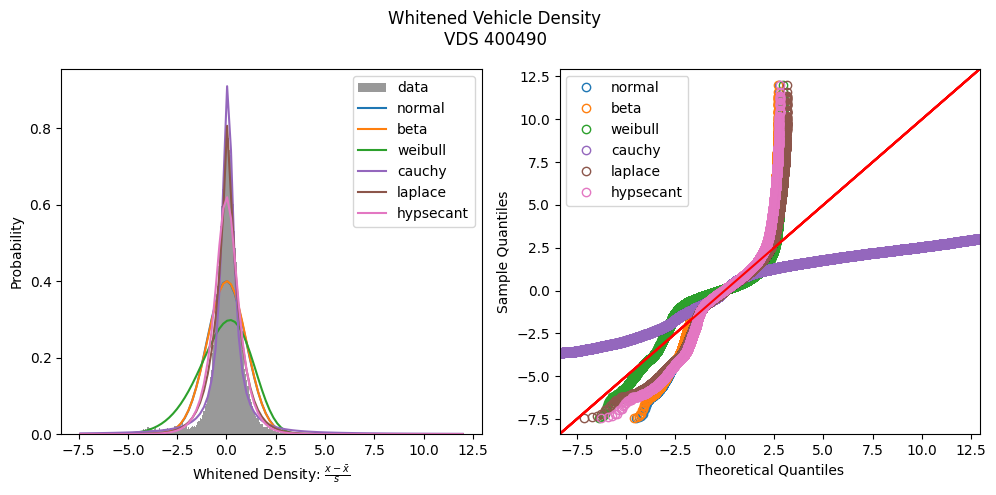

In [48]:
from scipy.stats import laplace, genhyperbolic

# Generate a histogram of the whitened timeseries
data = whitened_df['whitened_data'].dropna()
x = np.linspace(data.min(), data.max(), 100)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# Use 'density=True' so the histogram area sums to 1, matching the PDF
ax1.hist(data, bins=1000, density=True, alpha=0.4, color='k', label='data')

# Fit a normal distribution to the data
mu, sigma = norm.fit(data)
normal_dist = norm(mu, sigma)
normal_pdf = norm.pdf(x, mu, sigma)

# Fit a beta distribution to the data
a, b, loc1, scale1 = beta.fit(data)
beta_dist = beta(a,b,loc1,scale1)
beta_pdf = beta.pdf(x, a, b, loc1, scale1)

# Fit a weibull distribution to the data
c, loc2, scale2 = weibull_min.fit(data)
weibull_dist = weibull_min(c, loc2, scale2)
weibull_pdf = weibull_min.pdf(x, c, loc2, scale2)

# Fit a cauchy distribution to the data
loc3, scale3 = cauchy.fit(data)
cauchy_dist = cauchy(loc3, scale3)
cauchy_pdf = cauchy.pdf(x, loc3, scale3)

# Fit a laplace distribution to the data
loc4, scale4 = laplace.fit(data)
laplace_dist = laplace(loc4, scale4)
laplace_pdf = laplace.pdf(x, loc4, scale4)

# Fit a hypsecant distribution to the data
loc5, scale5 = hypsecant.fit(data)
hypsecant_dist = hypsecant(loc5, scale5)
hypsecant_pdf = hypsecant.pdf(x, loc5, scale5)

# Fit a hyperbolic distribution to the data
# p, a, b, loc, scale = genhyperbolic.fit(data)
# hyperbolic_dist = genhyperbolic(p,a,b,loc,scale)
# hyperbolic_pdf = genhyperbolic.pdf(x, p, a, b, loc, scale)

# Plot the fitted distribution curves
ax1.plot(x, normal_pdf, 'tab:blue', label='normal')
ax1.plot(x, beta_pdf, 'tab:orange', label='beta')
ax1.plot(x, weibull_pdf, 'tab:green', label='weibull')
ax1.plot(x, cauchy_pdf, 'tab:purple', label='cauchy')
ax1.plot(x, laplace_pdf, 'tab:brown', label='laplace')
ax1.plot(x, hypsecant_pdf, 'tab:pink', label='hypsecant')
#ax1.plot(x, hyperbolic_pdf, 'cyan', label='hyperbolic')

# Add the QQ plots
sm.qqplot(data=whitened_df['whitened_data'], dist=normal_dist, ax=ax2, line='45', label='normal', markerfacecolor='none', markeredgecolor='tab:blue')
sm.qqplot(data=whitened_df['whitened_data'], dist=beta_dist, ax=ax2, line='45', label='beta', markerfacecolor='none', markeredgecolor='tab:orange')
sm.qqplot(data=whitened_df['whitened_data'], dist=weibull_dist, ax=ax2, line='45', label='weibull', markerfacecolor='none', markeredgecolor='tab:green')
sm.qqplot(data=whitened_df['whitened_data'], dist=cauchy_dist, ax=ax2, line='45', label='cauchy', markerfacecolor='none', markeredgecolor='tab:purple')
sm.qqplot(data=whitened_df['whitened_data'], dist=laplace_dist, ax=ax2, line='45', label='laplace', markerfacecolor='none', markeredgecolor='tab:brown')
sm.qqplot(data=whitened_df['whitened_data'], dist=hypsecant_dist, ax=ax2, line='45', label='hypsecant', markerfacecolor='none', markeredgecolor='tab:pink')
#sm.qqplot(data=whitened_df['whitened_data'], dist=hyperbolic_dist, ax=ax2, line='45', label='hyperbolic', markerfacecolor='none', markeredgecolor='cyan')

# Add plot elements
ax1.set_xlabel(f"Whitened {metric.title()}: " + "$\\frac{x-\\bar{x}}{s}$")
ax1.set_ylabel("Probability")
ax1.legend()
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.legend()
plt.suptitle(f"Whitened Vehicle {metric.title()}\nVDS {station_id}")

# Fix spacing
plt.tight_layout()

# Show
plt.show()

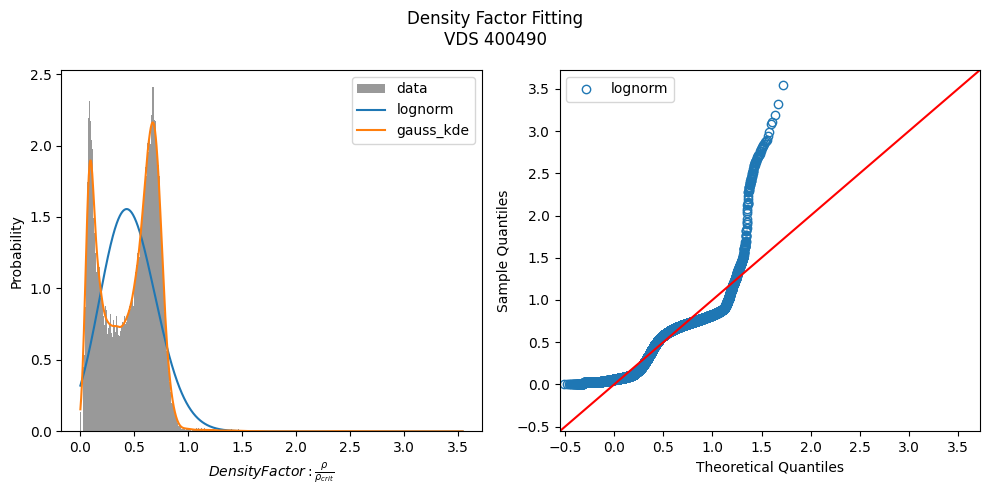

In [24]:
# Let's look at the distribution of the density factor!
from scipy.stats import gamma, gaussian_kde, lognorm

# Generate a histogram of the whitened timeseries
data = whitened_df['density_factor']
x = np.linspace(data.min(), data.max(), 1000)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

# Use 'density=True' so the histogram area sums to 1, matching the PDF
ax1.hist(data, bins=1000, density=True, alpha=0.4, color='k', label='data')

# Fit a gaussian kernel-density estimate
kde = gaussian_kde(data)
kde_pdf = kde(x)

# Fit a lognormal distribution to the data
s, loc1, scale1 = lognorm.fit(data)
lognorm_dist = lognorm(s, loc1, scale1)
lognorm_pdf = lognorm.pdf(x, s, loc1, scale1)

# Plot the fitted distribution curves
ax1.plot(x, lognorm_pdf, 'tab:blue', label='lognorm')
ax1.plot(x, kde_pdf, 'tab:orange', label='gauss_kde')


# Add the QQ plots
sm.qqplot(data=whitened_df['density_factor'], dist=lognorm_dist, ax=ax2, line='45', label='lognorm', markerfacecolor='none', markeredgecolor='tab:blue')

# Add plot elements
ax1.set_xlabel("$Density Factor: \\frac{\\rho}{\\rho_{crit}}$")
ax1.set_ylabel("Probability")
ax1.legend()
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.legend()
plt.suptitle(f"Density Factor Fitting\nVDS {station_id}")

# Fix spacing
plt.tight_layout()

# Show
plt.show()

In [49]:
summary = {
    'station_id':[],
    'skew':[],
    'kurtosis':[]
}

station_ids = [int(filename.split(".csv")[0]) for filename in os.listdir(timeseries_directory) if (filename.endswith(".csv")) and (not filename.startswith("V"))]
metric = 'density'

for idx, station_id in enumerate(station_ids):
    print(f"Working on station {idx+1}/{len(station_ids)}")
    timeseries_filename = f"timeseries_data/{station_id}.csv"
    timeseries_path = os.path.join(root_path, timeseries_filename)

    # Load data
    detector_metadata = get_metadata_series_by_id(metadata_df, station_id)
    timeseries_df = load_timeseries_by_id(station_id=station_id)
    df = normalize_timeseries(detector_metadata=detector_metadata, timeseries_df=timeseries_df)
    whitened_df = whiten_timeseries(df, metric=metric, rho_crit=None)

    # Calculate kurtosis and skew
    skew = whitened_df['whitened_data'].skew()
    kurt = whitened_df['whitened_data'].kurt()

    # Add to summary
    summary['station_id'].append(station_id)
    summary['skew'].append(skew)
    summary['kurtosis'].append(kurt)

# Turn it into a DataFrame!
stats_df = pd.DataFrame(summary)

Working on station 1/111
Working on station 2/111
Working on station 3/111
Working on station 4/111
Working on station 5/111
Working on station 6/111
Working on station 7/111
Working on station 8/111
Working on station 9/111
Working on station 10/111
Working on station 11/111
Working on station 12/111
Working on station 13/111
Working on station 14/111
Working on station 15/111
Working on station 16/111
Working on station 17/111
Working on station 18/111
Working on station 19/111
Working on station 20/111
Working on station 21/111
Working on station 22/111
Working on station 23/111
Working on station 24/111
Working on station 25/111
Working on station 26/111
Working on station 27/111
Working on station 28/111
Working on station 29/111
Working on station 30/111
Working on station 31/111
Working on station 32/111
Working on station 33/111
Working on station 34/111
Working on station 35/111
Working on station 36/111
Working on station 37/111
Working on station 38/111
Working on station 39

array([[<Axes: title={'center': 'skew'}, ylabel='Station ID'>,
        <Axes: title={'center': 'kurtosis'}, ylabel='Station ID'>]],
      dtype=object)

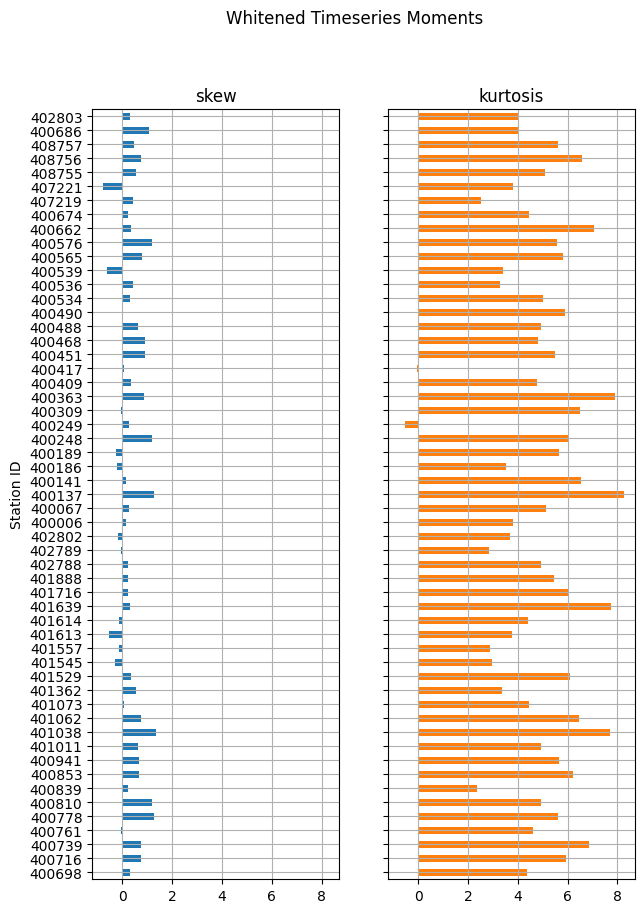

In [71]:
stats_df.dropna().set_index('station_id').plot(kind='barh', figsize=(7,10), subplots=True, sharey=True, layout=(1,2), ylabel="Station ID", grid=True, legend=False, title='Whitened Timeseries Moments')

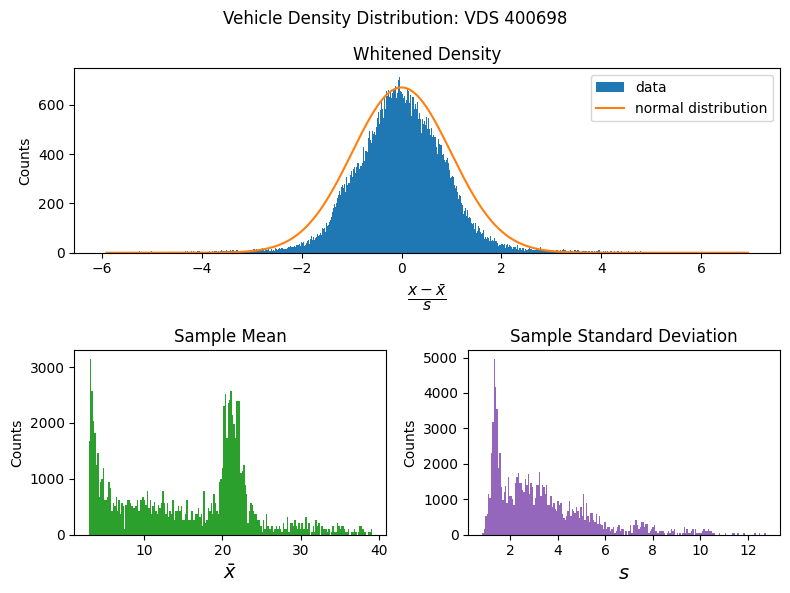

In [7]:
fig = plt.figure(figsize=(8, 6))

gs = fig.add_gridspec(2, 2)

# First row: one subplot spanning both columns
ax_top = fig.add_subplot(gs[0, :])

# Second row: two subplots, one per column
ax_bottom_left = fig.add_subplot(gs[1, 0])
ax_bottom_right = fig.add_subplot(gs[1, 1])

# Plot histogram of centered flow timeseries
(n,bins,patches) = ax_top.hist(whitened_df['whitened_data'], bins=1000, label='data')

# Fit a Gaussian curve to the distribution
A = n[np.argmin(abs(bins))]
y = A * np.exp(-0.5 * ((bins - mu) / sigma) ** 2)

# Plot the Gaussian
ax_top.plot(bins, y, label='normal distribution')

# Plot histogram of means
ax_bottom_left.hist(whitened_df['mean'], bins=200, color='tab:green')

# Plot histogram of std_devs
ax_bottom_right.hist(whitened_df['std_dev'], bins=200, color="tab:purple")

# Add axes elements
ax_top.set_xlabel("$\\frac{x-\\bar{x}}{s}$", fontsize=16)
ax_top.set_ylabel("Counts")
ax_top.set_title(f"Whitened {metric.title()}")
ax_top.legend()

ax_bottom_left.set_xlabel("$\\bar{x}$", fontsize=14)
ax_bottom_left.set_ylabel("Counts")
ax_bottom_left.set_title("Sample Mean")

ax_bottom_right.set_xlabel("$s$", fontsize=14)
ax_bottom_right.set_ylabel("Counts")
ax_bottom_right.set_title("Sample Standard Deviation")

plt.suptitle(f"Vehicle {metric.title()} Distribution: VDS {station_id}")
plt.tight_layout()
plt.show()


<Axes: xlabel='whitened_data', ylabel='shift1'>

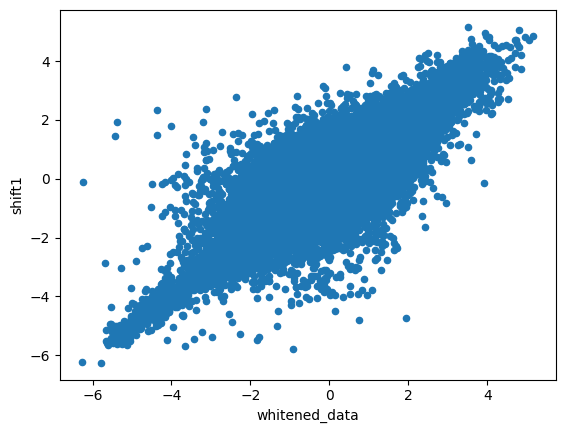

In [20]:
# NOTE: Unfinished
## Let's build a full autocorrelation heatmap to determine whether we've produced a weakly stationary dataset!
ndays = 7
periods = ndays * 24 * 12
nlags = periods-1
acf_df = whitened_df.loc[:,['timestamp', 'weekday', '5min_block', 'mean', 'std_dev', 'whitened_data']]
acf_df['shift1'] = acf_df['whitened_data'].shift(periods=-1)
acf_df.loc[:, ["whitened_data", "shift1"]].plot(x='whitened_data', y='shift1', kind='scatter')

In [56]:
# Calculate autocorrelation
ndays = 1
periods = ndays * 24 * 12
nlags = periods-1
acf = stattools.acf(whitened_df['whitened_data'], nlags=nlags, missing='conservative', fft=True, adjusted=True)
raw_acf = stattools.acf(df['normalized_density_[veh/mi-lane]'], nlags=nlags, missing='conservative', fft=True, adjusted=True)
times = pd.date_range(start='2026-01-01 00:00:00', periods=periods, freq='5min')
stats_df = pd.DataFrame(data={'whitened_acf':acf, 'raw_acf': raw_acf}, index=times)
stats_df

,whitened_acf,raw_acf
2026-01-01 00:00:00,1.000000,1.000000
2026-01-01 00:05:00,0.883101,0.979467
2026-01-01 00:10:00,0.847162,0.968522
2026-01-01 00:15:00,0.815049,0.957755
2026-01-01 00:20:00,0.787687,0.947808
...,...,...
2026-01-01 23:35:00,0.216580,0.763218
2026-01-01 23:40:00,0.218381,0.765995
2026-01-01 23:45:00,0.220128,0.768761
2026-01-01 23:50:00,0.221926,0.771650


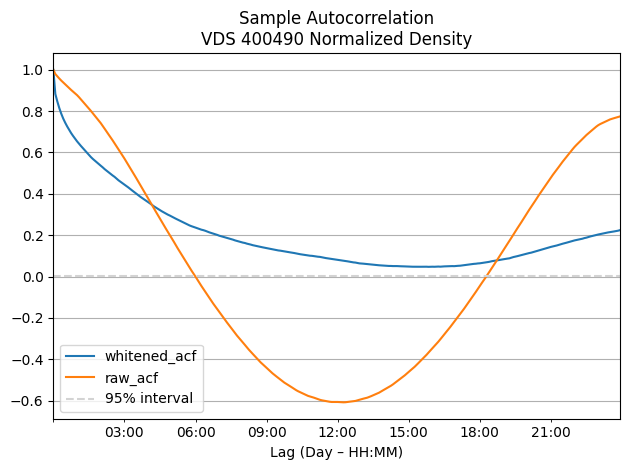

In [57]:
# Visualize!
ax = stats_df.plot()
interval = 2/np.sqrt(len(whitened_df))
ax.axhline(interval, color='lightgrey', linestyle='--', label='95% interval')

# Force ticks every 12 hours
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0,12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d - %H:%M'))
ax.tick_params(axis='x', labelrotation=45)

plt.xlabel("Lag (Day – HH:MM)")
plt.title(f"Sample Autocorrelation\nVDS {station_id} Normalized {metric.title()}")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


## Cross-correlations
Now let's start looking at some temporal-spatial dependencies in the data – e.g., how does flow upstream affect density downstream?
For this, we'll want to use our graph representation of the network.

In the meantime, let's use a mock example

In [22]:
import networkx as nx

def build_mock_roadway():
    # Create a directed graph
    G = nx.DiGraph()

    # Add nodes
    G.add_nodes_from([
        "A", "B", "C", "D", "E", "F"
    ])

    # Add directed edges with Station ID as an attribute
    G.add_edge("A", "B", station_id=400490, station_type="Mainline")
    G.add_edge("C", "B", station_id=402965, station_type="On Ramp")
    G.add_edge("B", "D", station_id=401888, station_type="Mainline")
    G.add_edge("D", "E", station_id=400137, station_type="Mainline")
    G.add_edge("D", "F", station_id=402967, station_type="Off Ramp")

    return G

# Build the roadway
# i880_nb = build_mock_roadway()        # Mock version

i880_nb = Freeway(
    links_filepath=GMNS_LINKS_FILEPATH,
    nodes_filepath=GMNS_NODES_FILEPATH,
    detector_metadata_filepath=CALTRANS_VDS_METADATA_FILEPATH,
    detector_timeseries_data_directory=CALTRANS_VDS_TIMESERIES_DIRECTORY_PATH,
    postmile_filepath=POSTMILE_FILEPATH,
    bounding_filepath=BOUNDING_FILEPATH,
    direction="N",
    vds_crs="EPSG:32610",
    postmile_crs="EPSG:32610",
    boundary_crs="EPSG:32610",
    common_crs="EPSG:32610",
    postmile_start=POSTMILE_START,
    postmile_end=POSTMILE_END,
    additional_offramp_node_ids=ADDITIONAL_OFFRAMP_NODE_IDS,
    additional_onramp_node_ids=ADDITIONAL_ONRAMP_NODE_IDS,
    mainline_node_ids_to_exclude=MAINLINE_NODE_IDS_TO_EXCLUDE,
    link_to_station_override=NB_LINK_TO_STATION_OVERRIDE,
)

In [11]:
def find_crosscorrelations(G: nx.DiGraph, metric_x: str = 'flow', metric_y: str = 'flow', nperiods: int = 24*12):
    # Prepare a dictionary for results
    results = {}

    # Traverse the edges in the graph
    for u, v, data in G.edges(data=True):        
        # Calculate CCF between this detector and every upstream detector located k=1 hops away
        for idx, pred in enumerate(G.predecessors(u)):
            if idx == 0:
                # Get the ID and whitened timeseries of the VDS for the edge
                current_station_id = data["station_id"]
                detector_metadata = get_metadata_series_by_id(metadata_df, station_id)
                current_station_timeseries = load_timeseries_by_id(station_id=str(current_station_id))
                current_station_timeseries = normalize_timeseries(detector_metadata=detector_metadata, timeseries_df=current_station_timeseries)
                print(f"Whitening timeseries for VDS: {current_station_id}")
                current_station_whitened_timeseries = whiten_timeseries(current_station_timeseries, metric_x)

            # Get the ID and whitened timeseries of the VDS for upstream edge
            edge_data = G[pred][u]
            upstream_station_id = edge_data["station_id"]
            detector_metadata = get_metadata_series_by_id(metadata_df, upstream_station_id)
            upstream_station_timeseries = load_timeseries_by_id(station_id=str(upstream_station_id))
            upstream_station_timeseries = normalize_timeseries(detector_metadata=detector_metadata, timeseries_df=upstream_station_timeseries)
            print(f"Whitening timeseries for VDS: {upstream_station_id}")
            upstream_station_whitened_timeseries = whiten_timeseries(upstream_station_timeseries, metric=metric_y)

            # Calculate cross-correlation
            ccf = stattools.ccf(x=current_station_whitened_timeseries['whitened_data'], y=upstream_station_whitened_timeseries['whitened_data'], nlags=periods, fft=True, adjusted=True)
            print(ccf[:6])

            # Add to results dictionary
            results[f'{current_station_id}_{metric_x}_{upstream_station_id}_{metric_y}'] = ccf
        
    # Save length of timeseries data used to construct ccf
    n = len(upstream_station_whitened_timeseries)

    # Construct dataframe from results
    times = pd.date_range(start='2026-01-01 00:00:00', periods=nperiods, freq='5min')
    ccf_df = pd.DataFrame(data=results, index=times)
    ccf_df = ccf_df.dropna(how='all', axis=1)

    return ccf_df, n


In [19]:
ccf_df, n = find_crosscorrelations(G=i880_nb)
ccf_df

Whitening timeseries for VDS: 401888
Whitening timeseries for VDS: 400490
[0.50140804 0.41906365 0.38421899 0.37245222 0.36324353 0.35195871]
Whitening timeseries for VDS: 402965


/Users/robstallman/.pyenv/versions/transportation-models-env/lib/python3.10/site-packages/scipy/signal/_signaltools.py:265: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return convolve(in1, _reverse_and_conj(in2), mode, method)


[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400137
Whitening timeseries for VDS: 401888
[0.6270952  0.51252107 0.49448868 0.48465031 0.47490645 0.46502132]
Whitening timeseries for VDS: 402967
Whitening timeseries for VDS: 401888
[nan nan nan nan nan nan]


/Users/robstallman/.pyenv/versions/transportation-models-env/lib/python3.10/site-packages/scipy/signal/_signaltools.py:265: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  return convolve(in1, _reverse_and_conj(in2), mode, method)


,401888_flow_400490_flow,400137_flow_401888_flow
2026-01-01 00:00:00,0.501408,0.627095
2026-01-01 00:05:00,0.419064,0.512521
2026-01-01 00:10:00,0.384219,0.494489
2026-01-01 00:15:00,0.372452,0.484650
2026-01-01 00:20:00,0.363244,0.474906
...,...,...
2026-01-01 23:35:00,0.124956,0.197516
2026-01-01 23:40:00,0.127143,0.199488
2026-01-01 23:45:00,0.129569,0.202416
2026-01-01 23:50:00,0.129901,0.202284


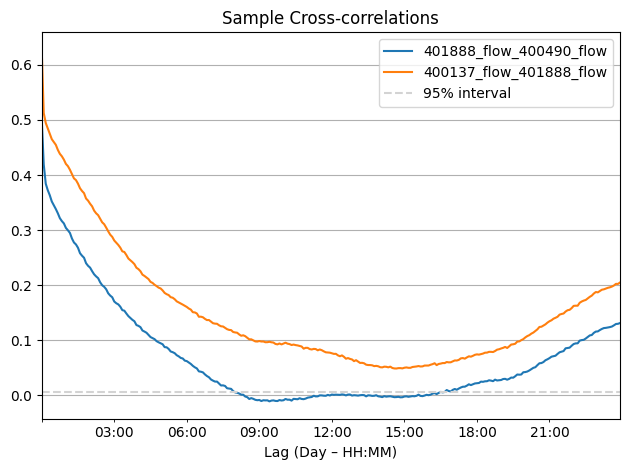

In [20]:
# Visualize!
ax = ccf_df.plot()
interval = 2/np.sqrt(n)
ax.axhline(interval, color='lightgrey', linestyle='--', label='95% interval')

# Force ticks every 12 hours
ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0,12]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d - %H:%M'))
ax.tick_params(axis='x', labelrotation=45)

plt.xlabel("Lag (Day – HH:MM)")
plt.title(f"Sample Cross-correlations")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

## Graph-based CCFs
We'll generate some novel CCF plots here. Instead of looking at two detectors and their CCF over different lags, we'll fix the lag and instead inspect how the CCF varies as you move away spatially. 
In order to do this, we'll want to use our actual representation of the roadway.

In [34]:
# Helper function
def get_whitened_timeseries(station_id, metric):
    detector_metadata = get_metadata_series_by_id(metadata_df, station_id)
    station_timeseries = load_timeseries_by_id(timeseries_directory=timeseries_directory, station_id=str(station_id))
    station_timeseries = normalize_timeseries(detector_metadata=detector_metadata, timeseries_df=station_timeseries)
    print(f"Whitening timeseries for VDS: {station_id}")
    whitened_timeseries = whiten_timeseries(station_timeseries, metric)
    return whitened_timeseries

# Setup
metric_x = 'flow'
metric_y = 'flow'
periods = 3*12     # 3 hours-worth
G = i880_nb.graph
whitened_timeseries_dict = {}
results = {}
times = pd.date_range(start='2026-01-01 00:00:00', periods=periods, freq='5min')

# Traverse graph
counter = 0
for u,v,data in G.edges(data=True):
    # Get the ID and whitened timeseries of the VDS for the edge
    current_station_id = data['static']["Station ID"]
    current_station_type = data['static']['link_type']
    # Don't use virtual stations or ramps
    if "V" in str(current_station_id) or current_station_type != "Mainline":
        continue
    current_station_whitened_timeseries = whitened_timeseries_dict.get(current_station_id, get_whitened_timeseries(current_station_id, metric_x))
    if current_station_id not in whitened_timeseries_dict.keys():
        whitened_timeseries_dict[current_station_id] = current_station_whitened_timeseries

    # Prepare dictionary for CCFs
    station_ccfs = {}
    
    # Get the k upstream stations
    upstream_stations = i880_nb.get_k_upstream_stations(node=u, k=6, edge_type='Mainline')
    for k_hops, station_list in upstream_stations.items():
        # Since we're interested in mainline stations only, there should only be one station in the list
        if len(station_list) > 0:
            upstream_station_id = station_list[0]
            if "V" in str(upstream_station_id):
                # skip
                continue
        else:
            # skip
            continue

        # Load the timeseries
        upstream_station_whitened_timeseries = whitened_timeseries_dict.get(upstream_station_id, get_whitened_timeseries(upstream_station_id, metric_y))
        if upstream_station_id not in whitened_timeseries_dict.keys():
            whitened_timeseries_dict[upstream_station_id] = upstream_station_whitened_timeseries

        # Calculate cross-correlation
        ccf = stattools.ccf(x=current_station_whitened_timeseries['whitened_data'], y=upstream_station_whitened_timeseries['whitened_data'], nlags=periods, fft=False, adjusted=True)
        print(ccf[:6])

        # Add to CCFs dictionary
        station_ccfs[f'{k_hops}_x={metric_x}_y={metric_y}'] = ccf
    
    # Convert CCFs to DataFrame
    ccf_df = pd.DataFrame(data=station_ccfs, index=times)
    results[current_station_id] = ccf_df

    counter += 1
    if counter > 5:
        break

Whitening timeseries for VDS: 400536
Whitening timeseries for VDS: 401529
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400534
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400539
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400674
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 401011
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 401011
Whitening timeseries for VDS: 401545
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400716
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400137
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 401888
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400490
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400761
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400761
Whitening timeseries for VDS: 400137
Whitening timeseries for VDS: 401888
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400490
[nan nan nan nan nan nan]
Whitening timeseries for VDS: 400

## TO-DO:
The ccf calculation function that we're using here doesn't have a keyword argument to specify how to treat NaNs (unlike `acf`), so right now this is a bit messy when one of the timeseries has NaNs:

In [75]:
metric_x = 'flow'; metric_y = 'flow'
current_station_id = 401888
detector_metadata = get_metadata_series_by_id(metadata_df, station_id)
current_station_timeseries = load_timeseries_by_id(station_id=str(current_station_id))
current_station_timeseries = normalize_timeseries(detector_metadata=detector_metadata, timeseries_df=current_station_timeseries)
print(f"Whitening timeseries for VDS: {current_station_id}")
current_station_whitened_timeseries = whiten_timeseries(current_station_timeseries, metric_x)
upstream_station_id = 402965
detector_metadata = get_metadata_series_by_id(metadata_df, upstream_station_id)
upstream_station_timeseries = load_timeseries_by_id(station_id=str(upstream_station_id))
upstream_station_timeseries = normalize_timeseries(detector_metadata=detector_metadata, timeseries_df=upstream_station_timeseries)
print(f"Whitening timeseries for VDS: {upstream_station_id}")
upstream_station_whitened_timeseries = whiten_timeseries(upstream_station_timeseries, metric=metric_y)

Whitening timeseries for VDS: 401888
Whitening timeseries for VDS: 402965


<Axes: xlabel='timestamp'>

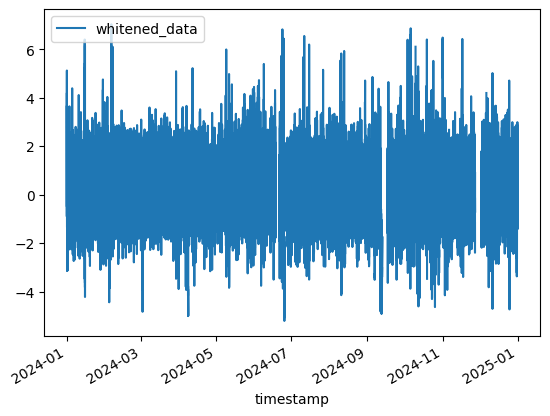

In [81]:
#stattools.ccf(x=current_station_whitened_timeseries['whitened_data'], y=upstream_station_whitened_timeseries['whitened_data'], nlags=periods, fft=True, adjusted=True)
upstream_station_whitened_timeseries.loc[:, ['timestamp', 'whitened_data']].set_index("timestamp").plot()